## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer

## Functions

In [2]:
def recovery_calculation(data, C='rougher'):
    """
    Esta función calcula la recuperación rougher o final.

    Args:
        data: es el dataset con la información para el
        cálculo de la recuperación.
        C: por defecto es rougher pero también puede ser final.

    Return:
        La función regresa un Series con todos los valores.
    """
    if C == 'rougher':
        c = data['rougher.output.concentrate_au']
        f = data['rougher.input.feed_au']
        t = data['rougher.output.tail_au']
    elif C == 'final':
        c = data['final.output.concentrate_au']
        f = data['primary_cleaner.output.concentrate_au']
        t = data['secondary_cleaner.output.tail_au']

    recovery = ((c*(f-t))/(f*(c-t)))*100
    return recovery

def get_outliers(data, column):
    """
    Esta función calcula los valores atípicos de la columna en cuestión.

    Args:
        data: es el dataset con la información para el
        cálculo de los valores atípicos.
        column: es la columna o característica para calcular los valores.

    Return:
        La función regresa los indexes de los valores atípicos con respecto a
        la columna en cuestión.
    """
    
    Q1 = np.percentile(data[column], 25)
    Q3 = np.percentile(data[column], 75)
    IQR = Q3 - Q1

    low_lim = Q1 - 1.5*IQR
    max_lim = Q3 + 1.5*IQR

    return data[(data[column] <= low_lim) | (data[column] >= max_lim)].index

def eliminate_outliers(data, indexes):
    """
    Esta función elimina los valores atípicos previamente calculados.

    Args:
        data: es el dataset con la información para el
        cálculo de los valores atípicos.
        indexes: son los indexes correspondientes a los valores
        atípicos previamente calculados.

    Return:
        La función no regresa nada.
    """

    data.drop(indexes, inplace=True)

def sMAPE_calculation(target, target_predicted):
    """
    Esta función calcula el valor de sMAPE que se utilizará
    como métrica de evaluación para el modelo.

    Args:
        target: es un Series con los valores reales de los objetivos.
        target_predicted: es un Series con los valores predichos 
        por el modelo.

    Return:
        La función regresa el valor de la métrica sMAPE.
    """

    N = len(target)

    sMAPE = (1/N)*2*np.sum(abs(target_predicted - target)/(abs(target_predicted)+abs(target)))*100

    return sMAPE

def final_sMAPE_calculation(sMAPEr, sMAPEf):
    """
    Esta función calcula el valor de sMAPE final que se 
    utilizará como una segunda métrica de evaluación para
    el modelo.

    Args:
        sMAPEr: es el valor de sMAPE para el objetivo de rougher
        previamente calculado.
        target_predicted: es el valor de sMAPE para el objetivo final
        previamente calculado.

    Return:
        La función regresa el valor de la métrica sMAPE final.
    """

    sMAPE_final = 0.25*sMAPEr+0.75*sMAPEf

    return sMAPE_final


## Data loading

In [3]:
gold_recovery_full = pd.read_csv(r"C:\Users\paul_\OneDrive\Documentos\Python Scripts\ml_model_to_predict_amount_of_gold_mined\gold_recovery_full.csv")

gold_recovery_train = pd.read_csv(r"C:\Users\paul_\OneDrive\Documentos\Python Scripts\ml_model_to_predict_amount_of_gold_mined\gold_recovery_train.csv")

gold_recovery_test = pd.read_csv(r"C:\Users\paul_\OneDrive\Documentos\Python Scripts\ml_model_to_predict_amount_of_gold_mined\gold_recovery_test.csv")

## Data preprocessing

### Data examination

In [4]:
gold_recovery_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22716 entries, 0 to 22715
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                22716 non-null  object 
 1   final.output.concentrate_ag                         22627 non-null  float64
 2   final.output.concentrate_pb                         22629 non-null  float64
 3   final.output.concentrate_sol                        22331 non-null  float64
 4   final.output.concentrate_au                         22630 non-null  float64
 5   final.output.recovery                               20753 non-null  float64
 6   final.output.tail_ag                                22633 non-null  float64
 7   final.output.tail_pb                                22516 non-null  float64
 8   final.output.tail_sol                               22445 non-null  float64


In [5]:
gold_recovery_full.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-01-15 00:00:00,6.055403,9.889648,5.507324,42.192020,70.541216,10.411962,0.895447,16.904297,2.143149,...,14.016835,-502.488007,12.099931,-504.715942,9.925633,-498.310211,8.079666,-500.470978,14.151341,-605.841980
1,2016-01-15 01:00:00,6.029369,9.968944,5.257781,42.701629,69.266198,10.462676,0.927452,16.634514,2.224930,...,13.992281,-505.503262,11.950531,-501.331529,10.039245,-500.169983,7.984757,-500.582168,13.998353,-599.787184
2,2016-01-15 02:00:00,6.055926,10.213995,5.383759,42.657501,68.116445,10.507046,0.953716,16.208849,2.257889,...,14.015015,-502.520901,11.912783,-501.133383,10.070913,-500.129135,8.013877,-500.517572,14.028663,-601.427363
3,2016-01-15 03:00:00,6.047977,9.977019,4.858634,42.689819,68.347543,10.422762,0.883763,16.532835,2.146849,...,14.036510,-500.857308,11.999550,-501.193686,9.970366,-499.201640,7.977324,-500.255908,14.005551,-599.996129
4,2016-01-15 04:00:00,6.148599,10.142511,4.939416,42.774141,66.927016,10.360302,0.792826,16.525686,2.055292,...,14.027298,-499.838632,11.953070,-501.053894,9.925709,-501.686727,7.894242,-500.356035,13.996647,-601.496691


In [6]:
print(f"Gold recovery full dataset observations: {gold_recovery_full.shape[0]:,.2f} \nGold recovery full dataset characteristics: {gold_recovery_full.shape[1]}")

Gold recovery full dataset observations: 22,716.00 
Gold recovery full dataset characteristics: 87


In [7]:
print(f"Gold recovery full dataset characteristics count \n{gold_recovery_full.dtypes.value_counts()}")

Gold recovery full dataset characteristics count 
float64    86
object      1
Name: count, dtype: int64


**Observations:** The source dataset contains 22,716 observations and 87 characteristics in total. However, several of the observations are not available, i.e., the dataset contains null. Of the 87 characteristics 86 are of type float and one of type object, which corresponds to the column date which, we will convert to datetime for a better handling.

In [8]:
gold_recovery_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


In [9]:
gold_recovery_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16860 entries, 0 to 16859
Data columns (total 87 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   date                                                16860 non-null  object 
 1   final.output.concentrate_ag                         16788 non-null  float64
 2   final.output.concentrate_pb                         16788 non-null  float64
 3   final.output.concentrate_sol                        16490 non-null  float64
 4   final.output.concentrate_au                         16789 non-null  float64
 5   final.output.recovery                               15339 non-null  float64
 6   final.output.tail_ag                                16794 non-null  float64
 7   final.output.tail_pb                                16677 non-null  float64
 8   final.output.tail_sol                               16715 non-null  float64


In [10]:
print(f"Gold recovery train dataset observations: {gold_recovery_train.shape[0]:,.2f} \nGold recovery train dataset characteristics: {gold_recovery_train.shape[1]}")

Gold recovery train dataset observations: 16,860.00 
Gold recovery train dataset characteristics: 87


In [11]:
print(f"Gold recovery train dataset characteristics count \n{gold_recovery_train.dtypes.value_counts()}")

Gold recovery train dataset characteristics count 
float64    86
object      1
Name: count, dtype: int64


**Observations:** The training dataset contains 16,860 observations, ~74% of the source dataset’s observations. The same number of features as the source dataset.

In [12]:
gold_recovery_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5856 entries, 0 to 5855
Data columns (total 53 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   date                                        5856 non-null   object 
 1   primary_cleaner.input.sulfate               5554 non-null   float64
 2   primary_cleaner.input.depressant            5572 non-null   float64
 3   primary_cleaner.input.feed_size             5856 non-null   float64
 4   primary_cleaner.input.xanthate              5690 non-null   float64
 5   primary_cleaner.state.floatbank8_a_air      5840 non-null   float64
 6   primary_cleaner.state.floatbank8_a_level    5840 non-null   float64
 7   primary_cleaner.state.floatbank8_b_air      5840 non-null   float64
 8   primary_cleaner.state.floatbank8_b_level    5840 non-null   float64
 9   primary_cleaner.state.floatbank8_c_air      5840 non-null   float64
 10  primary_clea

In [13]:
gold_recovery_test.head()

,date,primary_cleaner.input.sulfate,primary_cleaner.input.depressant,primary_cleaner.input.feed_size,primary_cleaner.input.xanthate,primary_cleaner.state.floatbank8_a_air,primary_cleaner.state.floatbank8_a_level,primary_cleaner.state.floatbank8_b_air,primary_cleaner.state.floatbank8_b_level,primary_cleaner.state.floatbank8_c_air,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,210.800909,14.993118,8.080000,1.005021,1398.981301,-500.225577,1399.144926,-499.919735,1400.102998,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,215.392455,14.987471,8.080000,0.990469,1398.777912,-500.057435,1398.055362,-499.778182,1396.151033,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,215.259946,12.884934,7.786667,0.996043,1398.493666,-500.868360,1398.860436,-499.764529,1398.075709,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,215.336236,12.006805,7.640000,0.863514,1399.618111,-498.863574,1397.440120,-499.211024,1400.129303,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,199.099327,10.682530,7.530000,0.805575,1401.268123,-500.808305,1398.128818,-499.504543,1402.172226,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


In [14]:
print(f"Gold recovery test dataset observations: {gold_recovery_test.shape[0]:,.2f} \nGold recovery test dataset characteristics: {gold_recovery_test.shape[1]}")

Gold recovery test dataset observations: 5,856.00 
Gold recovery test dataset characteristics: 53


In [15]:
print(f"Gold recovery test dataset characteristics count \n{gold_recovery_test.dtypes.value_counts()}")

Gold recovery test dataset characteristics count 
float64    52
object      1
Name: count, dtype: int64


**Observations:** The test dataset contains 5,856 observations, ~25% of the source dataset’s total observations, and 53 characteristics. An observable difference with the source and training dataset.

### Verification of recovery calculation

$$Recovery = {C(F - T) \over F(C - T)}*100$$

* C = **rougher.output.concentrate_au** / **final.output.concentrate_au**
* F = **rougher.input.feed_au** / **primary_cleaner.output.concentrate_au**
* T = **rougher.output.tail_au** / **secondary_cleaner.output.tail_au**

In [16]:
# Drop na values of rougher.output.recovery column from training dataset
train_na = gold_recovery_train.dropna(subset=['rougher.output.recovery'])

In [17]:
# Calculate the rougher output recovery manually
recovery_cal = recovery_calculation(train_na)
recovery_cal

0        87.107763
1        86.843261
2        86.842308
3        87.226430
4        86.688794
           ...    
16855    89.574376
16856    87.724007
16857    88.890579
16858    89.858126
16859    89.514960
Length: 14287, dtype: float64

In [18]:
# Calculate MAE between the manual calculation and the results already in the training dataset
print(f"MAE = {mean_absolute_error(train_na['rougher.output.recovery'], recovery_cal):.15f}")

MAE = 0.000000000000009


**Observations:** This means that there is no difference between the manual calculation and the training dataset data.

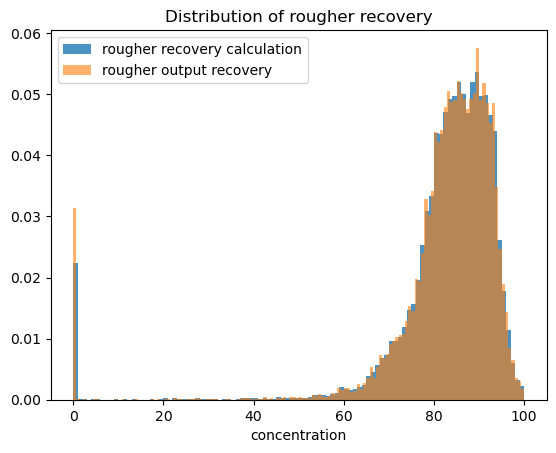

In [19]:
plt.hist(
    recovery_cal, label='rougher recovery calculation', bins=100, ec='black', alpha=0.8, density=True
)
plt.hist(
    train_na['rougher.output.recovery'], label='rougher output recovery', ec='black', bins=140, alpha=0.6, density=True
)

plt.xlabel('concentration')
plt.title('Distribution of rougher recovery')
plt.legend()
plt.show()

**Observations:** The distribution of both calculations is equal. They appear to follow the pattern of a normal distribution and tend to cluster towards a midpoint. They appear to be biased to the left, that is, they have a negative asymmetry.

### Analysis of missing features

In [20]:
# Extract the missing columns in the test dataset
cols_missing = gold_recovery_train.columns[~gold_recovery_train.columns.isin(gold_recovery_test.columns)].tolist()
print(f'There are {len(cols_missing)} missing columns in the test dataset.')

There are 34 missing columns in the test dataset.


In [21]:
# Print the missing columns
cols_missing

['final.output.concentrate_ag',
 'final.output.concentrate_pb',
 'final.output.concentrate_sol',
 'final.output.concentrate_au',
 'final.output.recovery',
 'final.output.tail_ag',
 'final.output.tail_pb',
 'final.output.tail_sol',
 'final.output.tail_au',
 'primary_cleaner.output.concentrate_ag',
 'primary_cleaner.output.concentrate_pb',
 'primary_cleaner.output.concentrate_sol',
 'primary_cleaner.output.concentrate_au',
 'primary_cleaner.output.tail_ag',
 'primary_cleaner.output.tail_pb',
 'primary_cleaner.output.tail_sol',
 'primary_cleaner.output.tail_au',
 'rougher.calculation.sulfate_to_au_concentrate',
 'rougher.calculation.floatbank10_sulfate_to_au_feed',
 'rougher.calculation.floatbank11_sulfate_to_au_feed',
 'rougher.calculation.au_pb_ratio',
 'rougher.output.concentrate_ag',
 'rougher.output.concentrate_pb',
 'rougher.output.concentrate_sol',
 'rougher.output.concentrate_au',
 'rougher.output.recovery',
 'rougher.output.tail_ag',
 'rougher.output.tail_pb',
 'rougher.output.ta

**Observations:** The test set does not contain 34 characteristics than the source and training sets do. All of them are float type that correspond to measurements or calculations of concentrations in different parts of the process. Most of the missing columns correspond to the final quantities of certain process steps, 'output'.

## Data processing and cleaning

We’ll start by adding the missing columns to the test set using the source set.

In [22]:
# Merge the full dataset with the test dataset on date column and left method
columns_for_merging = cols_missing.append('date')
full_test_data = gold_recovery_test.merge(gold_recovery_full[cols_missing], on='date', how='left')
full_test_data = full_test_data[gold_recovery_train.columns]
full_test_data.head()

,date,final.output.concentrate_ag,final.output.concentrate_pb,final.output.concentrate_sol,final.output.concentrate_au,final.output.recovery,final.output.tail_ag,final.output.tail_pb,final.output.tail_sol,final.output.tail_au,...,secondary_cleaner.state.floatbank4_a_air,secondary_cleaner.state.floatbank4_a_level,secondary_cleaner.state.floatbank4_b_air,secondary_cleaner.state.floatbank4_b_level,secondary_cleaner.state.floatbank5_a_air,secondary_cleaner.state.floatbank5_a_level,secondary_cleaner.state.floatbank5_b_air,secondary_cleaner.state.floatbank5_b_level,secondary_cleaner.state.floatbank6_a_air,secondary_cleaner.state.floatbank6_a_level
0,2016-09-01 00:59:59,7.578381,10.466295,11.990938,40.743891,70.273583,12.688885,3.844413,11.075686,4.537988,...,12.023554,-497.795834,8.016656,-501.289139,7.946562,-432.317850,4.872511,-500.037437,26.705889,-499.709414
1,2016-09-01 01:59:59,7.813838,10.581152,12.216172,39.604292,68.910432,12.829171,3.918901,11.132824,4.675117,...,12.058140,-498.695773,8.130979,-499.634209,7.958270,-525.839648,4.878850,-500.162375,25.019940,-499.819438
2,2016-09-01 02:59:59,7.623392,10.424024,12.313710,40.724190,68.143213,12.977846,4.026561,10.990134,4.828907,...,11.962366,-498.767484,8.096893,-500.827423,8.071056,-500.801673,4.905125,-499.828510,24.994862,-500.622559
3,2016-09-01 03:59:59,8.552457,10.503229,13.074570,39.290997,67.776393,12.451947,3.780702,11.155935,4.969620,...,12.033091,-498.350935,8.074946,-499.474407,7.897085,-500.868509,4.931400,-499.963623,24.948919,-498.709987
4,2016-09-01 04:59:59,8.078781,10.222788,12.475427,40.254524,61.467078,11.827846,3.632272,11.403663,5.256806,...,12.025367,-500.786497,8.054678,-500.397500,8.107890,-509.526725,4.957674,-500.360026,25.003331,-500.856333


In [23]:
print(f"Gold recovery full test dataset observations: {full_test_data.shape[0]:,.2f} \nGold recovery full test dataset characteristics: {full_test_data.shape[1]}")

Gold recovery full test dataset observations: 5,856.00 
Gold recovery full test dataset characteristics: 87


In [24]:
# Extract the missing columns in the new full test dataset
missing_columns = gold_recovery_train.columns[~gold_recovery_train.columns.isin(full_test_data.columns)].tolist()
print(f'There are {len(missing_columns)} missing columns in the test dataset.')

There are 0 missing columns in the test dataset.


**Observations:** The new test set now contains all 87 characteristics. To deal with the null data, we will use the previous value to deal with the null values since, as it says in the description the near parameters in time are usually similar.

In [25]:
# Get how many null values we have before treating the null values
print(gold_recovery_full.isna().sum().sort_values(ascending=False).head(20))

rougher.output.recovery                   3119
rougher.output.tail_ag                    2737
rougher.output.tail_au                    2736
rougher.output.tail_sol                   2736
rougher.input.floatbank11_xanthate        2257
secondary_cleaner.output.tail_sol         2215
final.output.recovery                     1963
rougher.calculation.au_pb_ratio           1627
primary_cleaner.input.sulfate             1609
primary_cleaner.input.depressant          1546
rougher.input.floatbank10_sulfate         1301
primary_cleaner.input.xanthate            1151
primary_cleaner.output.concentrate_sol     798
rougher.input.floatbank11_sulfate          678
rougher.state.floatbank10_e_air            620
rougher.input.feed_rate                    553
rougher.input.floatbank10_xanthate         469
primary_cleaner.output.concentrate_pb      448
rougher.input.feed_size                    439
final.output.concentrate_sol               385
dtype: int64


In [26]:
print(gold_recovery_train.isna().sum().sort_values(ascending=False).head(20))

rougher.output.recovery                     2573
rougher.output.tail_ag                      2250
rougher.output.tail_sol                     2249
rougher.output.tail_au                      2249
secondary_cleaner.output.tail_sol           1986
rougher.input.floatbank11_xanthate          1904
final.output.recovery                       1521
primary_cleaner.input.sulfate               1307
primary_cleaner.input.depressant            1262
rougher.calculation.au_pb_ratio             1242
rougher.input.floatbank10_sulfate           1044
primary_cleaner.input.xanthate               985
primary_cleaner.output.concentrate_sol       636
rougher.input.floatbank11_sulfate            623
rougher.state.floatbank10_e_air              603
rougher.input.feed_rate                      513
rougher.input.feed_size                      417
final.output.concentrate_sol                 370
secondary_cleaner.state.floatbank2_a_air     363
primary_cleaner.output.concentrate_pb        358
dtype: int64


In [27]:
print(full_test_data.isna().sum().sort_values(ascending=False).head(20))

rougher.output.recovery                   546
rougher.output.tail_ag                    487
rougher.output.tail_au                    487
rougher.output.tail_sol                   487
final.output.recovery                     442
rougher.calculation.au_pb_ratio           385
rougher.input.floatbank11_xanthate        353
primary_cleaner.input.sulfate             302
primary_cleaner.input.depressant          284
rougher.input.floatbank10_sulfate         257
secondary_cleaner.output.tail_sol         229
primary_cleaner.input.xanthate            166
primary_cleaner.output.concentrate_sol    162
final.output.tail_sol                     126
rougher.input.floatbank10_xanthate        123
primary_cleaner.output.concentrate_pb      90
primary_cleaner.output.tail_sol            70
rougher.input.feed_sol                     67
rougher.input.floatbank11_sulfate          55
rougher.input.feed_rate                    40
dtype: int64


In [29]:
df_full = gold_recovery_full.fillna(method='ffill')
df_train = gold_recovery_train.fillna(method='ffill')
df_test = full_test_data.fillna(method='ffill')

C:\Users\paul_\AppData\Local\Temp\ipykernel_32976\1511913441.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_full = gold_recovery_full.fillna(method='ffill')
C:\Users\paul_\AppData\Local\Temp\ipykernel_32976\1511913441.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_train = gold_recovery_train.fillna(method='ffill')
C:\Users\paul_\AppData\Local\Temp\ipykernel_32976\1511913441.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_test = full_test_data.fillna(method='ffill')


In [30]:
# Get how many null values we have after treating the null values
print(df_full.isna().sum().sort_values(ascending=False).head())

date                                 0
rougher.state.floatbank10_b_air      0
rougher.state.floatbank10_f_air      0
rougher.state.floatbank10_e_level    0
rougher.state.floatbank10_e_air      0
dtype: int64


In [31]:
print(df_train.isna().sum().sort_values(ascending=False).head())

date                                 0
rougher.state.floatbank10_b_air      0
rougher.state.floatbank10_f_air      0
rougher.state.floatbank10_e_level    0
rougher.state.floatbank10_e_air      0
dtype: int64


In [32]:
print(df_test.isna().sum().sort_values(ascending=False).head())

date                                 0
rougher.state.floatbank10_b_air      0
rougher.state.floatbank10_f_air      0
rougher.state.floatbank10_e_level    0
rougher.state.floatbank10_e_air      0
dtype: int64


**Observations:** Now that we no longer have null values, let’s check for outliers that the datasets might have.

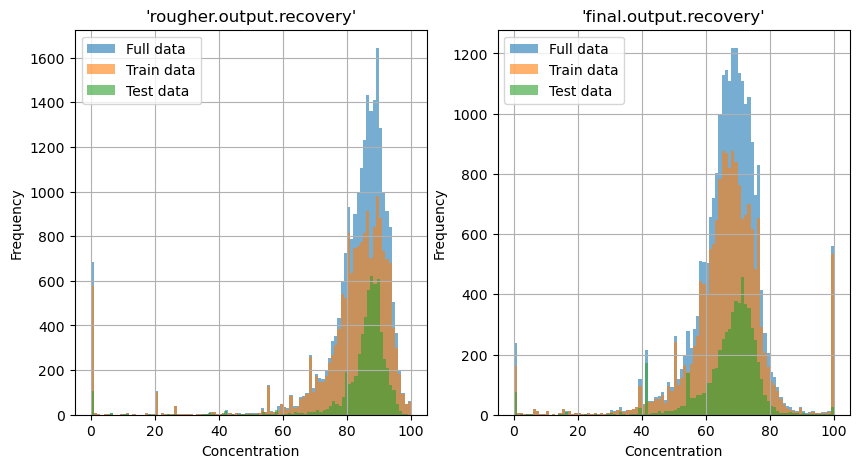

In [33]:
# Create a figure with two subplot to observe if any atypical observations in the data, outliers.
fig, (a, b) = plt.subplots(1, 2, figsize=(10, 5))

# Graph 'rougher.output.recovery' data for three datasets
df_full['rougher.output.recovery'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Full data'
)
df_train['rougher.output.recovery'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Train data'
)
df_test['rougher.output.recovery'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Test data'
)

# Graph 'final.output.recovery' data for three datasets
df_full['final.output.recovery'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Full data'
)
df_train['final.output.recovery'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Train data'
)
df_test['final.output.recovery'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Test data'
)

a.set_title("'rougher.output.recovery'")
a.set_xlabel('Concentration')
a.set_ylabel('Frequency')
a.legend()

b.set_title("'final.output.recovery'")
b.set_xlabel('Concentration')
b.set_ylabel('Frequency')
b.legend()

plt.show()

Text(0.5, 1.0, 'Test dataset outliers visualization')

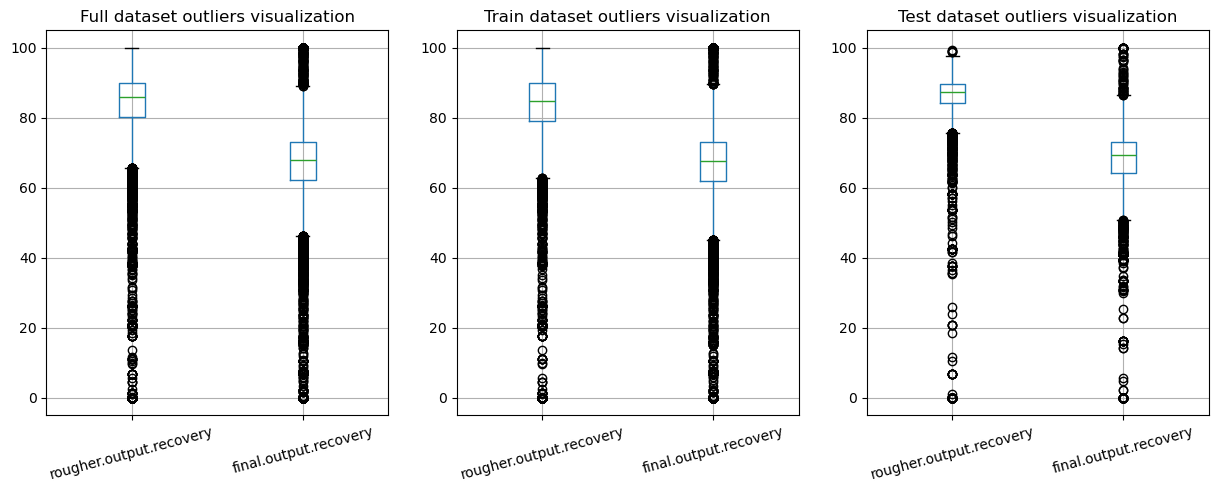

In [34]:
# Create a boxplot to better visualize the outliers
fig, (a, b, c) = plt.subplots(1, 3, figsize=(15, 5))

# Graph a sandbox for the full datasets for both characteristics
df_full[['rougher.output.recovery', 'final.output.recovery']].boxplot(
    ax=a, rot=15
)
a.set_title('Full dataset outliers visualization')

# Graph a sandbox for the train datasets for both characteristics
df_train[['rougher.output.recovery', 'final.output.recovery']].boxplot(
    ax=b, rot=15
)
b.set_title('Train dataset outliers visualization')

# Graph a sandbox for the train datasets for both characteristics
df_test[['rougher.output.recovery', 'final.output.recovery']].boxplot(
    ax=c, rot=15
)
c.set_title('Test dataset outliers visualization')

**Observations:** As can be seen in the figures above, datasets contain extreme values or outliers which could significantly deviate the overall pattern of the dataset and negatively affect the analysis, results and model. However, since we do not know the origin of these values, whether they are real values or the result of a measurement problem, we will not eliminate them until we know more about the source of these data.

## Data analysis

### Change in metal concentration (Ag, Au, Pb) depending on the purification stage.

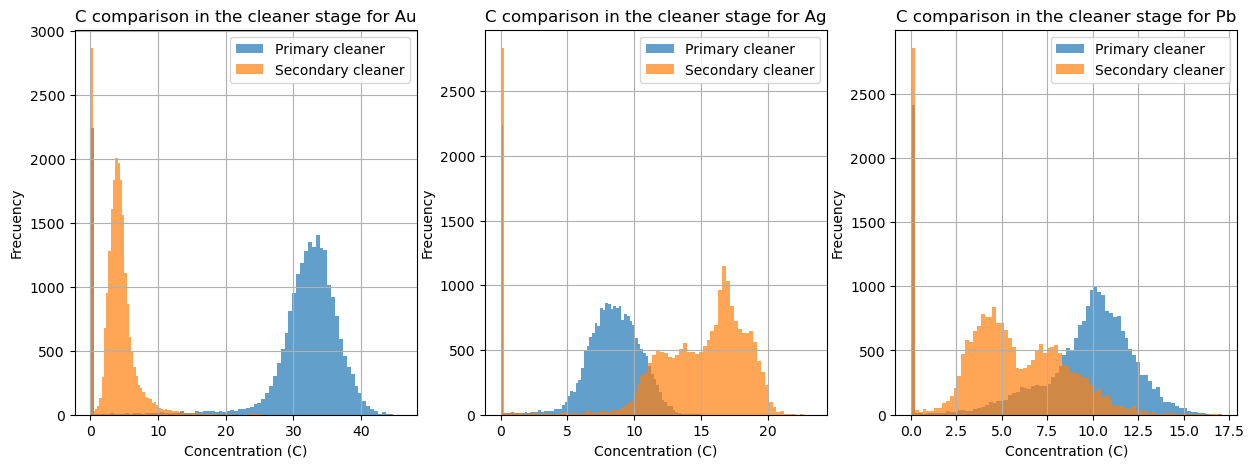

In [35]:
# Create a figure with three subplot to observe the changes in the metal's concentration in the cleaner stage.
fig, (a, b, c) = plt.subplots(1, 3, figsize=(15, 5))

# Show the concentration's change for Au
df_full['primary_cleaner.output.concentrate_au'].hist(
    ax=a, alpha=0.7, ec='black', bins=80, label='Primary cleaner'
)
df_full['secondary_cleaner.output.tail_au'].hist(
    ax=a, alpha=0.7, ec='black', bins=80, label='Secondary cleaner'
)
a.set_title('C comparison in the cleaner stage for Au')
a.set_xlabel('Concentration (C)')
a.set_ylabel('Frecuency')
a.legend()

# Show the concentration's change for Ag
df_full['primary_cleaner.output.concentrate_ag'].hist(
    ax=b, alpha=0.7, ec='black', bins=80, label='Primary cleaner'
)
df_full['secondary_cleaner.output.tail_ag'].hist(
    ax=b, alpha=0.7, ec='black', bins=80, label='Secondary cleaner'
)
b.set_title('C comparison in the cleaner stage for Ag')
b.set_xlabel('Concentration (C)')
b.set_ylabel('Frecuency')
b.legend()

# Show the concentration's change for Pb
df_full['primary_cleaner.output.concentrate_pb'].hist(
    ax=c, alpha=0.7, ec='black', bins=80, label='Primary cleaner'
)
df_full['secondary_cleaner.output.tail_pb'].hist(
    ax=c, alpha=0.7, ec='black', bins=80, label='Secondary cleaner'
)
c.set_title('C comparison in the cleaner stage for Pb')
c.set_xlabel('Concentration (C)')
c.set_ylabel('Frecuency')
c.legend()

plt.legend()
plt.show()

**Observations:** As we can see in the figure above, for gold metal (Au) the first stage displays data with a higher concentration than compared to the second purification stage, where the gold concentration decreases. However, for the silver metal (Ag) it is exactly the opposite, in the first stage of purification there is a lower concentration than in the second. And finally, for the lead metal (Pb), as with Au, a higher concentration is observed in the first stage compared to the second purification stage.

### Comparison of feed particle size distributions in training and test sets.

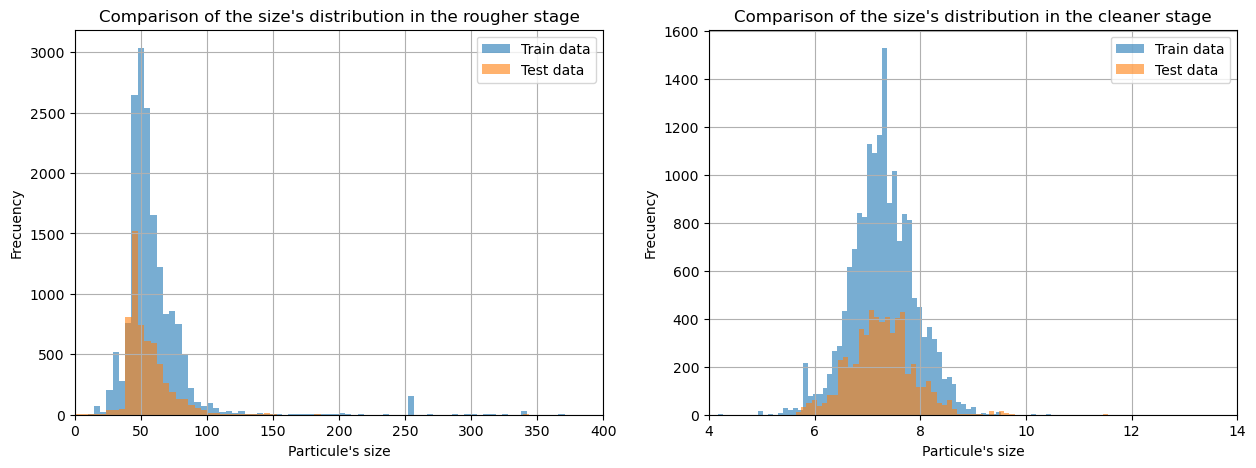

In [36]:
# Create a figure with two subplot to observe the distribution of the particules.
fig, (a, b) = plt.subplots(1, 2, figsize=(15, 5))

#
df_train['rougher.input.feed_size'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Train data'
)
df_test['rougher.input.feed_size'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Test data'
)
a.set_title("Comparison of the size's distribution in the rougher stage")
a.set_xlabel("Particule's size")
a.set_ylabel("Frecuency")
a.set_xlim(0, 400)
a.legend()

df_train['primary_cleaner.input.feed_size'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Train data'
)
df_test['primary_cleaner.input.feed_size'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Test data'
)
b.set_title("Comparison of the size's distribution in the cleaner stage")
b.set_xlabel("Particule's size")
b.set_ylabel("Frecuency")
b.set_xlim(4, 14)
b.legend()

plt.legend()
plt.show()

**Observations:** The comparison shows that the particle size distribution does not differ significantly. The only difference could be in the number of particles between datasets.

### Comparison of total concentrations of the three metals at different stages: raw material, rougher concentrate and final concentrate.

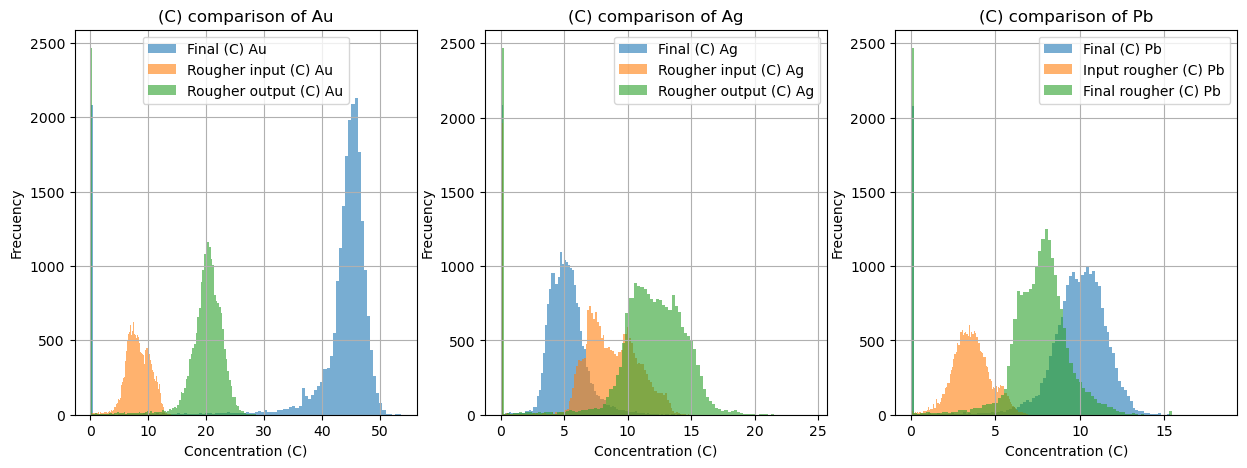

In [37]:
# Create a figure with three subplot to observe any abnormalies.
fig, (a, b, c) = plt.subplots(1, 3, figsize=(15, 5))

# Graph the three concentrations for Au
df_full['final.output.concentrate_au'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Final (C) Au'
)
df_full['rougher.input.feed_au'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Rougher input (C) Au'
)
df_full['rougher.output.concentrate_au'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Rougher output (C) Au'
)
a.set_title('(C) comparison of Au')
a.set_xlabel('Concentration (C)')
a.set_ylabel('Frecuency')
a.legend()

# Graph the three concentrations for Ag
df_full['final.output.concentrate_ag'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Final (C) Ag'
)
df_full['rougher.input.feed_ag'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Rougher input (C) Ag'
)
df_full['rougher.output.concentrate_ag'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Rougher output (C) Ag'
)
b.set_title('(C) comparison of Ag')
b.set_xlabel('Concentration (C)')
b.set_ylabel('Frecuency')
b.legend()

# Graph the three concentrations for Pb
df_full['final.output.concentrate_pb'].hist(
    ax=c, alpha=0.6, ec='black', bins=100, label='Final (C) Pb'
)
df_full['rougher.input.feed_pb'].hist(
    ax=c, alpha=0.6, ec='black', bins=100, label='Input rougher (C) Pb'
)
df_full['rougher.output.concentrate_pb'].hist(
    ax=c, alpha=0.6, ec='black', bins=100, label='Final rougher (C) Pb'
)
c.set_title('(C) comparison of Pb')
c.set_xlabel('Concentration (C)')
c.set_ylabel('Frecuency')
c.legend()


plt.show()

**Observations:** As can be seen in the figure below, at the beginning of the process, raw material (rougher input), there is a lower concentration for the metals of Au and Pb however for the Ag it happens the opposite, the concentration is higher at the beginning of the process. At the end of the whole process, the concentration of Au and Pb is significantly higher than at the beginning. However, it is interesting to note that the final concentration of Ag is considerably lower than the initial concentration.

As for abnormal values, we can see that there are outliers which were mentioned above, close to zero.

In [38]:
# Eliminate the outliers that were found in the previous analysis

# Select the columns to examine for outliers
columns_selected = [
    'final.output.concentrate_au', 'rougher.input.feed_au', 'rougher.output.concentrate_au',
    'final.output.concentrate_ag', 'rougher.input.feed_ag', 'rougher.output.concentrate_ag',
    'final.output.concentrate_pb', 'rougher.input.feed_pb', 'rougher.output.concentrate_pb'
]

# Make a copy of the original datasets to keep them safe
df_train_clean = df_train.copy()
df_test_clean = df_test.copy()
df_full_clean = df_full.copy()

# Select the datasets to examine
dfs = [df_full_clean, df_train_clean, df_test_clean]

# Use the functions to eliminate the outliers observed
for d in dfs:
    for c in columns_selected:
        indexes = get_outliers(d, c)
        eliminate_outliers(d, indexes)
        

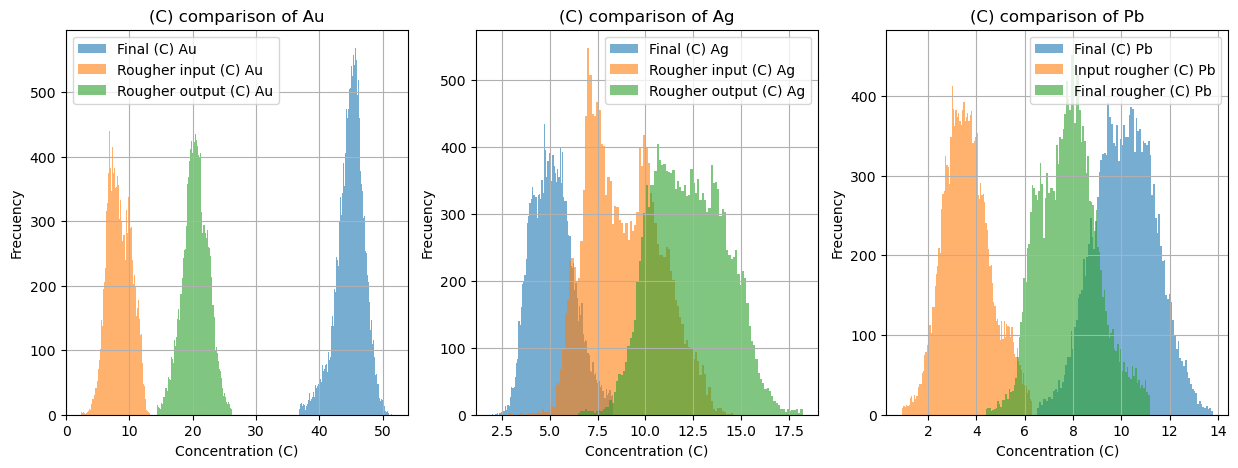

In [39]:
# Create a figure with three subplot to observe any abnormalies.
fig, (a, b, c) = plt.subplots(1, 3, figsize=(15, 5))

# Graph the three concentrations for Au
df_full_clean['final.output.concentrate_au'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Final (C) Au'
)
df_full_clean['rougher.input.feed_au'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Rougher input (C) Au'
)
df_full_clean['rougher.output.concentrate_au'].hist(
    ax=a, alpha=0.6, ec='black', bins=100, label='Rougher output (C) Au'
)
a.set_title('(C) comparison of Au')
a.set_xlabel('Concentration (C)')
a.set_ylabel('Frecuency')
a.legend()

# Graph the three concentrations for Ag
df_full_clean['final.output.concentrate_ag'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Final (C) Ag'
)
df_full_clean['rougher.input.feed_ag'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Rougher input (C) Ag'
)
df_full_clean['rougher.output.concentrate_ag'].hist(
    ax=b, alpha=0.6, ec='black', bins=100, label='Rougher output (C) Ag'
)
b.set_title('(C) comparison of Ag')
b.set_xlabel('Concentration (C)')
b.set_ylabel('Frecuency')
b.legend()

# Graph the three concentrations for Pb
df_full_clean['final.output.concentrate_pb'].hist(
    ax=c, alpha=0.6, ec='black', bins=100, label='Final (C) Pb'
)
df_full_clean['rougher.input.feed_pb'].hist(
    ax=c, alpha=0.6, ec='black', bins=100, label='Input rougher (C) Pb'
)
df_full_clean['rougher.output.concentrate_pb'].hist(
    ax=c, alpha=0.6, ec='black', bins=100, label='Final rougher (C) Pb'
)
c.set_title('(C) comparison of Pb')
c.set_xlabel('Concentration (C)')
c.set_ylabel('Frecuency')
c.legend()


plt.show()

**Observations:** As we can see, we have eliminated the outliers that we had observed in the previous figure.

## Building the model

In [40]:
# Create the features train and features test by dropping 'final.ouput.recovery' and 'rougher.output.recovery' characteristics as the objectives
features_train = df_train_clean.drop(
    ['date', 'final.output.recovery', 'rougher.output.recovery'], axis=1
)
target_train = df_train_clean[['final.output.recovery', 'rougher.output.recovery']]

### Cálculo del valor final de sMAPE.

$$sMAPE = {1 \over N}{\sum_{i=1}^{n}}{|y_i - \hat{y_i}| \over (|y_i|+|\hat{y_i}|)/2}*100$$

$$sMAPE final = {25\% * sMAPE(rougher) + 75\% * sMAPE(final)}$$

We will use these two formulas as metrics to measure the performance of built models.

In [41]:
sMAPE_scorer = make_scorer(sMAPE_calculation)

In [42]:
# Create a df to save the performance for each model
models_performance = pd.DataFrame(columns=['model', 'target', 'score'])

In [43]:
# Build a LinearRegression model as first model
for i in range(len(target_train.columns)):
    print(f'Evaluation of {target_train.columns[i]}')

    # Build the model
    model = LinearRegression()

    # Make the cross validation
    scores = cross_val_score(
        model, features_train, target_train.iloc[:, i], cv=5, scoring=sMAPE_scorer
    )
    mean_score = scores.mean()
    print(f'Score of the model evaluation: {mean_score}')

    models_performance.loc[len(models_performance) + 1] = {
        'model': model, 'target': target_train.columns[i], 'score': mean_score
    }

print(models_performance)

Evaluation of final.output.recovery
Score of the model evaluation: 3.0455772166654382
Evaluation of rougher.output.recovery
Score of the model evaluation: 2.7355001055893324
                model                   target     score
1  LinearRegression()    final.output.recovery  3.045577
2  LinearRegression()  rougher.output.recovery  2.735500


In [44]:
# Build a DecisionTreeRegressor model as first model
for i in range(len(target_train.columns)):
    print(f'Evaluation of {target_train.columns[i]}')

    # Build the model
    model = DecisionTreeRegressor(random_state=42)

    # Make the cross validation
    scores = cross_val_score(
        model, features_train, target_train.iloc[:, i], cv=5, scoring=sMAPE_scorer
    )
    mean_score = scores.mean()
    print(f'Score of the model evaluation: {mean_score}')

    models_performance.loc[len(models_performance) + 1] = {
        'model': model, 'target': target_train.columns[i], 'score': mean_score
    }

print(models_performance)

Evaluation of final.output.recovery
Score of the model evaluation: 1.7768208021987841
Evaluation of rougher.output.recovery
Score of the model evaluation: 1.6780847296193915
                                    model                   target     score
1                      LinearRegression()    final.output.recovery  3.045577
2                      LinearRegression()  rougher.output.recovery  2.735500
3  DecisionTreeRegressor(random_state=42)    final.output.recovery  1.776821
4  DecisionTreeRegressor(random_state=42)  rougher.output.recovery  1.678085


In [45]:
# Build a RandomForestRegressor model as first model
for i in range(len(target_train.columns)):
    print(f'Evaluation of {target_train.columns[i]}')

    # Build the model
    model = RandomForestRegressor(random_state=42)

    # Make the cross validation
    scores = cross_val_score(
        model, features_train, target_train.iloc[:, i], cv=5, scoring=sMAPE_scorer
    )
    mean_score = scores.mean()
    print(f'Score of the model evaluation: {mean_score}')

    models_performance.loc[len(models_performance) + 1] = {
        'model': model, 'target': target_train.columns[i], 'score': mean_score
    }

print(models_performance)

Evaluation of final.output.recovery
Score of the model evaluation: 1.049326590056098
Evaluation of rougher.output.recovery
Score of the model evaluation: 1.112808548667776
                                    model                   target     score
1                      LinearRegression()    final.output.recovery  3.045577
2                      LinearRegression()  rougher.output.recovery  2.735500
3  DecisionTreeRegressor(random_state=42)    final.output.recovery  1.776821
4  DecisionTreeRegressor(random_state=42)  rougher.output.recovery  1.678085
5  RandomForestRegressor(random_state=42)    final.output.recovery  1.049327
6  RandomForestRegressor(random_state=42)  rougher.output.recovery  1.112809


In [46]:
# Build a BaggingRegression model as first model
for i in range(len(target_train.columns)):
    print(f'Evaluation of {target_train.columns[i]}')

    # Build the model
    model = BaggingRegressor(random_state=42)

    # Make the cross validation
    scores = cross_val_score(
        model, features_train, target_train.iloc[:, i], cv=5, scoring=sMAPE_scorer
    )
    mean_score = scores.mean()
    print(f'Score of the model evaluation: {mean_score}')

    models_performance.loc[len(models_performance) + 1] = {
        'model': model, 'target': target_train.columns[i], 'score': mean_score
    }

print(models_performance)

Evaluation of final.output.recovery
Score of the model evaluation: 1.3013623607927736
Evaluation of rougher.output.recovery
Score of the model evaluation: 1.2476804723256234
                                    model                   target     score
1                      LinearRegression()    final.output.recovery  3.045577
2                      LinearRegression()  rougher.output.recovery  2.735500
3  DecisionTreeRegressor(random_state=42)    final.output.recovery  1.776821
4  DecisionTreeRegressor(random_state=42)  rougher.output.recovery  1.678085
5  RandomForestRegressor(random_state=42)    final.output.recovery  1.049327
6  RandomForestRegressor(random_state=42)  rougher.output.recovery  1.112809
7       BaggingRegressor(random_state=42)    final.output.recovery  1.301362
8       BaggingRegressor(random_state=42)  rougher.output.recovery  1.247680


                                    model                   target     score
1                      LinearRegression()    final.output.recovery  3.045577
2                      LinearRegression()  rougher.output.recovery  2.735500
3  DecisionTreeRegressor(random_state=42)    final.output.recovery  1.776821
4  DecisionTreeRegressor(random_state=42)  rougher.output.recovery  1.678085
5  RandomForestRegressor(random_state=42)    final.output.recovery  1.049327
6  RandomForestRegressor(random_state=42)  rougher.output.recovery  1.112809
7       BaggingRegressor(random_state=42)    final.output.recovery  1.301362
8       BaggingRegressor(random_state=42)  rougher.output.recovery  1.247680


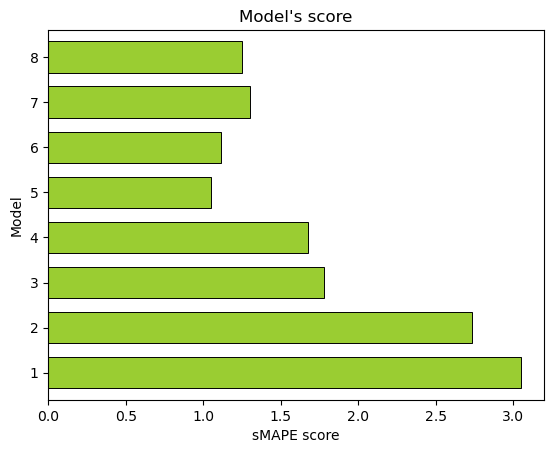

In [47]:
print(models_performance)

models_performance['score'].plot(
    kind='barh', color='yellowgreen', edgecolor='black', width=0.7, linewidth=0.7
)

plt.title("Model's score")
plt.xlabel('sMAPE score')
plt.ylabel('Model')
plt.show()

**Observations:** After training different models and evaluating them with the sMAPE metric, it can be concluded that the best model was number 5 and 6 corresponding to RandomForestRegressor(random_state=42). Therefore, this model will be used to predict the targets with the test set.

In [48]:
# Create the test features and test target
features_test = df_test_clean.drop(
    ['date', 'final.output.recovery', 'rougher.output.recovery'], axis=1
)
target_test = df_test_clean[['final.output.recovery', 'rougher.output.recovery']]

In [49]:
# Build the RandomForestRegressor model and evaluate it for 'rougher.output.recovery'
model = RandomForestRegressor(random_state=42)

model.fit(features_train, target_train['rougher.output.recovery'])

rougher_predictions = model.predict(features_test)

rougher_sMAPE = sMAPE_calculation(target_test['rougher.output.recovery'], rougher_predictions)

print(f'sMAPE score for rougher.output.recovery: {rougher_sMAPE}')

sMAPE score for rougher.output.recovery: 0.8760939793816706


In [50]:
# Build the RandomForestRegressor model and evaluate it for 'final.output.recovery'
model = RandomForestRegressor(random_state=42)

model.fit(features_train, target_train['final.output.recovery'])

final_predictions = model.predict(features_test)

final_sMAPE = sMAPE_calculation(target_test['final.output.recovery'], final_predictions)

print(f'sMAPE score for final.output.recovery: {final_sMAPE}')

sMAPE score for final.output.recovery: 0.7218869805005704


In [51]:
# Calculate final sMAPE score
print(f'Final sMAPE score: {final_sMAPE_calculation(rougher_sMAPE, final_sMAPE)}')

Final sMAPE score: 0.7604387302208454


## Conclusions

Finally, we can conclude that, as can be seen in the previous point, our model obtained a final score of the sMAPE metric of ~0.76 which tells us about a model with good fit and performance. It is also possible to rescue, that the project has been concluded well, having developed all points of work.